<a href="https://colab.research.google.com/github/AYCDJ/Monkeytype-Data/blob/main/Monkeytype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Notebook is being made in order to have analysis and document my typing data from Monkeytype, a typing platform made to help improve typing speed and accuracy.

I only have access to data entries ~34,000 and above because Monkeytype only keeps track of the last 1000 tests.


In [12]:
# Access to google drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Variables for future use

DRIVE_FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/monkeytype' # If using this notebook you will need to update this with the path in your own drive, (CASE SENSITIVE)
TIMEZONE = 'America/Chicago'  # This is my own timezone, can be updated to display your own if its different


In [37]:
# Imports and colors for style
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# These colors were chosen in order to resemble my chosen theme in monkeytype, seen below
'''
https://monkeytype.com/settings?highlight=theme
:root {
    --bg-color: #1c1e26;
    --main-color: #c4a88a;
    --caret-color: #bbbbbb;
    --sub-color: #db886f;
    --sub-alt-color: #17181f;
    --text-color: #bbbbbb;
    --error-color: #d55170;
    --error-extra-color: #ff3d3d;
    --colorful-error-color: #d55170;
    --colorful-error-extra-color: #d55170;
}
'''

MCOLOR      = '#c4a88a'  # Main color
SCOLOR      = '#db886f'  # Sub colro
BG          = '#1c1e26'  # Background color
PANEL       = '#17181f'
TCOLOR      = '#d1d0c5'  # Text color
ERROR_COLOR = '#d55170'
GREY        = '#bbbbbb'
WHITE       = '#ffffff'

# Style configuration, customizes BG color, gridlines, tick colors etc.
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   PANEL,
    'axes.edgecolor':   '#2a2a2a',
    'axes.labelcolor':  SCOLOR,
    'xtick.color':      SCOLOR,
    'ytick.color':      SCOLOR,
    'text.color':       TCOLOR,
    'grid.color':       '#232323',
    'grid.linestyle':   '-',
    'grid.linewidth':   0.6,
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'font.family':      'monospace',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# Function to apply consistent title style
def title(ax, text):
    ax.set_title(text, color=MCOLOR, fontsize=13, pad=10, loc='left')

#

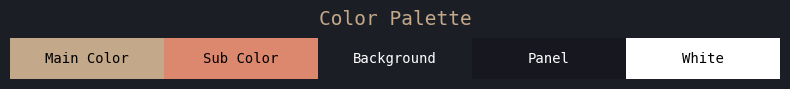

In [15]:
# The following is just to view colors, no need to run code

fig, ax = plt.subplots(figsize=(8, 1))

colors = [MCOLOR, SCOLOR, BG, PANEL, WHITE]
labels = ['Main Color', 'Sub Color', 'Background', 'Panel', 'White']
x_pos = np.arange(len(colors))

ax.barh(0, [1]*len(colors), color=colors, height=1)
ax.set_yticks([])
ax.set_xticks(x_pos + 0.5)
ax.set_xticklabels(labels, color=TCOLOR)
ax.set_xlim(0, len(colors))
ax.set_facecolor(BG)
ax.tick_params(axis='x', colors=TCOLOR)

# Individual widths and positions for seperation/labeling
widths = [1] * len(colors)
starts = np.arange(len(colors))

for i, color in enumerate(colors):
  rect = plt.Rectangle((starts[i], -0.5), widths[i], 1, facecolor=color)
  ax.add_patch(rect)
  ax.text(starts[i] + widths[i]/2, 0, labels[i], ha='center', va='center', color='white' if color in [BG, PANEL] else 'black', fontsize = 10)

ax.set_xlim(0, len(colors))
ax.set_ylim(-0.5, 0.5)
ax.axis('off')

plt.title('Color Palette', color=MCOLOR, fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [33]:
# Loading and removing duplicate entries

csv_files = sorted(glob.glob(os.path.join(DRIVE_FOLDER_PATH, '*.csv')))
print(f'Found {len(csv_files)} files:')
for f in csv_files:
    print(f' {os.path.basename(f)}')

if not csv_files:
    raise FileNotFoundError(f'No CSV files in: {DRIVE_FOLDER_PATH}')

raw = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f'\nTotal rows: {len(raw):,}')

df = raw.drop_duplicates(subset=['_id']).copy()
print(f'Total rows after removing duplicates: {len(df):,}')
print(f'Total rows removed: {len(raw) - len(df):,}')

Found 2 files:
 01results.csv
 02results.csv

Total rows: 2,003
Total rows after removing duplicates: 1,461
Total rows removed: 542


In [35]:
# Parsing data and cleaning, timestamps are in Unix milliseconds

df['date'] = (pd.to_datetime(df['timestamp'], unit='ms', utc = True)
              .dt.tz_convert(TIMEZONE))
df = df.sort_values('date').reset_index(drop=True)

# Stats, format is - correct;incorrect;extra;missed
char_parts = df['charStats'].str.split(';', expand=True).astype(float)
df['chars_correct']     = char_parts[0]
df['chars_incorrect']   = char_parts[1]
df['chars_extra']       = char_parts[2]
df['chars_missed']      = char_parts[3]
df['chars_total']       = df[['chars_correct', 'chars_incorrect', 'chars_extra', 'chars_missed']].sum(axis=1)

# Columns
df['mode_label'] = df['mode'] + ' ' + df['mode2'].astype(str)
df['test_num']   = range(1, len(df) + 1)
df['week']       = df['date'].dt.to_period('W')
df['day']        = df['date'].dt.date

# Rolling average
N = max(10, len(df) // 30)
df['wpm_roll']  = df['wpm'].rolling(N, min_periods=1).mean()
df['acc_roll']  = df['acc'].rolling(N, min_periods=1).mean()
df['raw_roll']  = df['rawWpm'].rolling(N, min_periods=1).mean()
df['cons_roll'] = df['consistency'].rolling(N, min_periods=1).mean()

print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Total tests: {len(df):,}')
print(f'Rolling window: {N} tests')
df[['wpm','acc','rawWpm','consistency','restartCount', 'testDuration']].describe().round(2)

Date range: 2026-05-04 to 2026-05-19
Total tests: 1,461
Rolling window: 48 tests


,wpm,acc,rawWpm,consistency,restartCount,testDuration
count,1461.00,1461.00,1461.00,1461.00,1461.0,1461.00
mean,111.21,94.53,116.74,74.71,0.0,14.99
std,10.47,2.80,9.94,6.30,0.0,0.00
min,81.64,83.94,88.87,52.39,0.0,14.99
25%,104.04,92.65,109.66,70.36,0.0,14.99
50%,110.48,94.64,116.84,74.67,0.0,14.99
75%,118.49,96.64,123.29,78.99,0.0,14.99
max,144.89,100.00,147.29,91.70,0.0,15.00


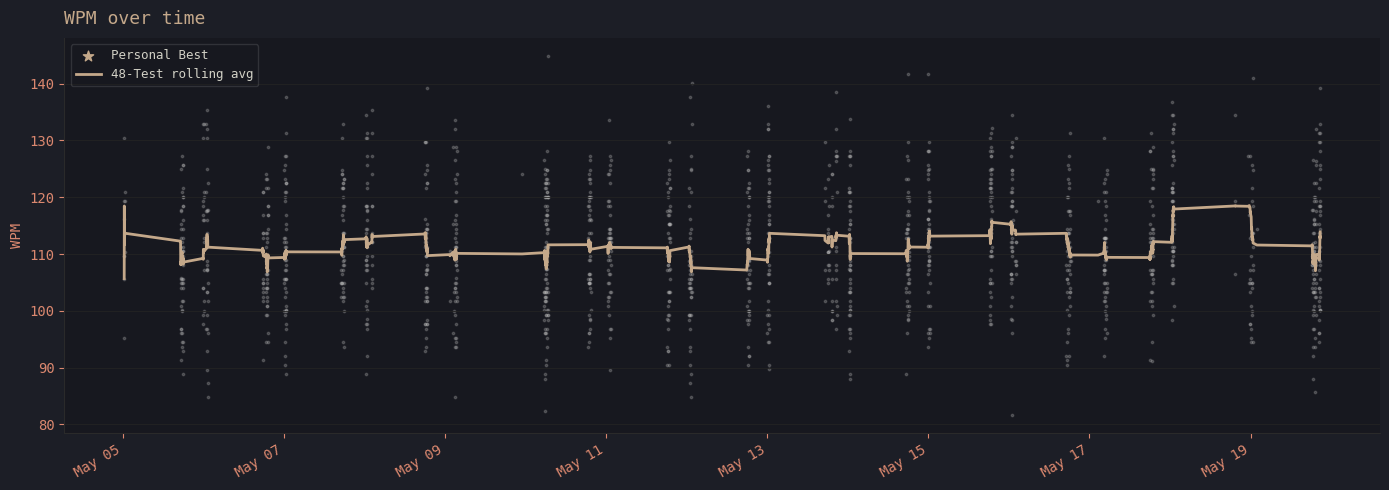

In [38]:
# WPM Progress

fig, ax = plt.subplots(figsize=(14, 5))

# Personal best
pb_mask = df['isPb'] == True
ax.scatter(df.loc[pb_mask, 'date'], df.loc[pb_mask, 'wpm'], s=60, color=MCOLOR, zorder=5, marker='*', label='Personal Best')

ax.scatter(df['date'], df['wpm'], s=3, alpha=0.25, color=GREY, zorder=1)
ax.plot(df['date'], df['wpm_roll'], color=MCOLOR, lw=2, label=f'{N}-Test rolling avg')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=30, ha='right')
ax.set_ylabel('WPM')
title(ax, 'WPM over time')
ax.legend(framealpha=0.15, fontsize=9)
plt.tight_layout()
plt.show()